In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("ggplot")

In [68]:
nav = pd.read_csv("../data/processed/02_nav_history_clean.csv")
performance = pd.read_csv("../data/processed/07_scheme_performance_clean.csv")
transactions = pd.read_csv("../data/processed/08_investor_transactions_clean.csv")
holdings = pd.read_csv("../data/processed/09_portfolio_holdings_clean.csv")

In [69]:
nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(["amfi_code", "date"])

nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [70]:
results = []

for code, df in nav.groupby("amfi_code"):

    returns = df["daily_return"].dropna()

    # Skip funds with no return data
    if len(returns) == 0:
        continue

    # 95% Historical VaR (5th percentile)
    var95 = np.percentile(returns, 5)

    # CVaR = Average return below VaR
    cvar95 = returns[returns <= var95].mean()

    results.append({
        "amfi_code": code,
        "VaR_95": var95,
        "CVaR_95": cvar95
    })

risk_report = pd.DataFrame(results)

risk_report = risk_report.sort_values("VaR_95")

risk_report.head()

,amfi_code,VaR_95,CVaR_95
22,119599,-0.026859,-0.032384
17,119095,-0.026188,-0.031667
4,101207,-0.026021,-0.032459
11,118634,-0.025438,-0.032304
21,119598,-0.024507,-0.030595


In [71]:
risk_report.to_csv("../reports/var_cvar_report.csv", index=False)

print("var_cvar_report.csv saved successfully!")

var_cvar_report.csv saved successfully!


In [72]:
nav["amfi_code"].unique()[:10]

array([100016, 100025, 100033, 101206, 101207, 101208, 102885, 102886,
       102887, 118632])

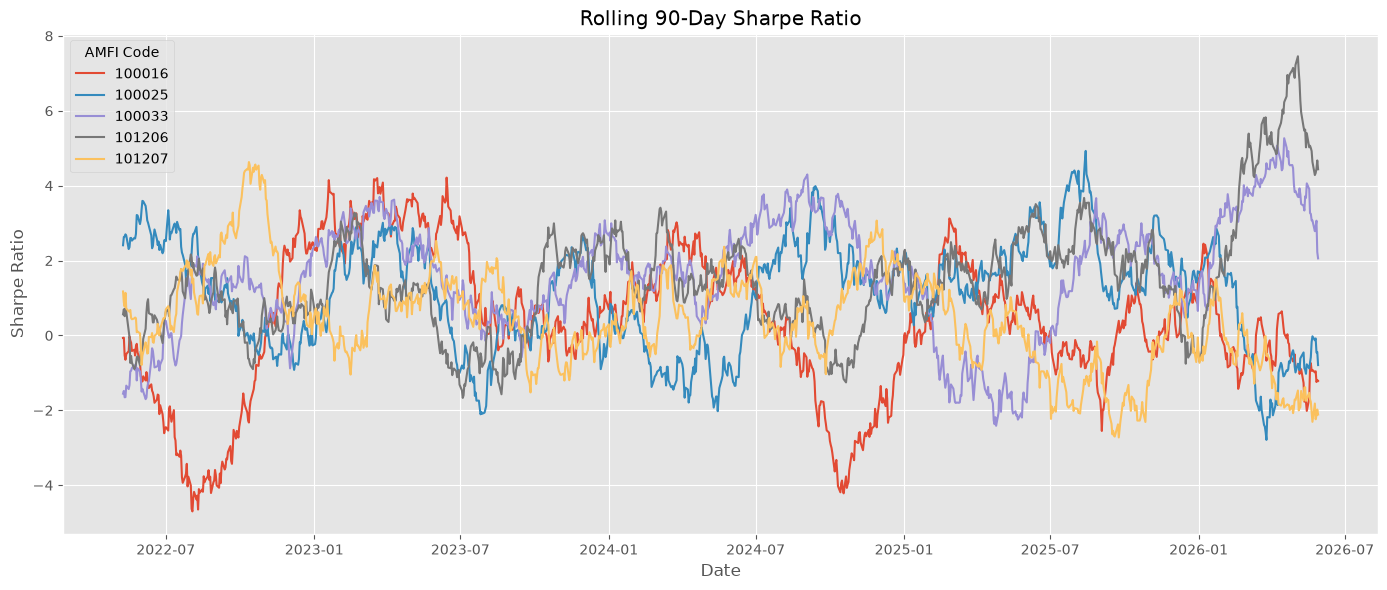

In [73]:
plt.figure(figsize=(14,6))

top5 = nav["amfi_code"].unique()[:5]

for code in top5:

    df = nav[nav["amfi_code"] == code].copy()

    rolling_sharpe = (
        df["daily_return"].rolling(90).mean()
        /
        df["daily_return"].rolling(90).std()
    ) * np.sqrt(252)

    plt.plot(df["date"], rolling_sharpe, label=str(code))

plt.title("Rolling 90-Day Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend(title="AMFI Code")
plt.grid(True)

plt.tight_layout()

plt.savefig("../reports/rolling_sharpe_chart.png")

plt.show()

In [74]:
transactions["transaction_date"] = pd.to_datetime(transactions["transaction_date"])

In [75]:
first_year = (
    transactions.groupby("investor_id")["transaction_date"]
    .min()
    .dt.year
)

transactions["cohort"] = transactions["investor_id"].map(first_year)

In [76]:
cohort_summary = (
    transactions.groupby("cohort")
    .agg(
        Average_Investment=("amount_inr", "mean"),
        Total_Investment=("amount_inr", "sum")
    )
    .reset_index()
)

In [77]:
top_fund = (
    transactions.groupby(["cohort", "amfi_code"])
    .size()
    .reset_index(name="count")
    .sort_values(["cohort", "count"], ascending=[True, False])
    .groupby("cohort")
    .first()
    .reset_index()
)

cohort_summary = cohort_summary.merge(
    top_fund[["cohort", "amfi_code"]],
    on="cohort"
)

cohort_summary.rename(
    columns={"amfi_code": "Top_Fund"},
    inplace=True
)

cohort_summary

,cohort,Average_Investment,Total_Investment,Top_Fund
0,2024,107422.541832,3491125187,148568
1,2025,109158.577061,30455243,119599


In [78]:
transactions = transactions.sort_values(
    ["investor_id", "transaction_date"]
)

In [79]:
transactions["gap_days"] = (
    transactions.groupby("investor_id")["transaction_date"]
    .diff()
    .dt.days
)

In [80]:
sip = (
    transactions.groupby("investor_id")
    .agg(
        Transactions=("transaction_date", "count"),
        Average_Gap=("gap_days", "mean")
    )
)

sip = sip[sip["Transactions"] >= 6]

In [81]:
sip["Status"] = np.where(
    sip["Average_Gap"] > 35,
    "At-Risk",
    "Healthy"
)

sip.head()

,Transactions,Average_Gap,Status
investor_id,,,
INV000002,6,82.800000,At-Risk
INV000004,9,53.375000,At-Risk
INV000005,8,52.000000,At-Risk
INV000006,6,99.000000,At-Risk
INV000008,8,50.285714,At-Risk


In [82]:
performance["risk_grade"].unique()

<StringArray>
['Moderate', 'Very High', 'Low', 'High', 'Moderately High']
Length: 5, dtype: str

In [83]:
# Convert percentage to decimal
holdings["weight"] = holdings["weight_pct"] / 100

# Calculate HHI for each fund
hhi = (
    holdings.groupby("amfi_code")["weight"]
    .apply(lambda x: (x ** 2).sum())
    .reset_index()
)

hhi.columns = ["amfi_code", "HHI"]

# Sort from highest concentration to lowest
hhi = hhi.sort_values("HHI", ascending=False)

hhi.head(10)

,amfi_code,HHI
11,119092,0.206448
3,101207,0.200700
18,119599,0.174751
4,102885,0.174709
7,118632,0.168298
29,148568,0.167930
21,120505,0.157570
22,120506,0.153794
27,125498,0.152414
23,120841,0.149680


In [84]:
hhi.to_csv("../reports/sector_hhi_report.csv", index=False)

print("sector_hhi_report.csv saved successfully!")

sector_hhi_report.csv saved successfully!


# Advanced Insights

## 1. Historical VaR & CVaR
The fund with AMFI Code **119599** recorded the most negative 95% Historical VaR, indicating the highest downside risk among the analyzed funds. The corresponding CVaR shows that this fund experiences comparatively larger losses during extreme market conditions.

## 2. Rolling 90-Day Sharpe Ratio
The Rolling 90-Day Sharpe Ratio analysis shows how the risk-adjusted performance of funds changes over time. Funds with consistently higher Sharpe Ratios delivered better returns for the level of risk taken.

## 3. Investor Cohort Analysis
Investor cohort analysis identified differences in investment behaviour across cohorts by comparing average investment amounts, total investments, and the most preferred mutual funds.

## 4. SIP Continuity Analysis
Investors with an average gap greater than **35 days** between SIP transactions were classified as **At-Risk**, while the remaining investors demonstrated more consistent investment behaviour.

## 5. Sector HHI Concentration
The highest Herfindahl-Hirschman Index (HHI) was observed for **AMFI Code 119092 (HHI = 0.206448)**, indicating the most concentrated portfolio. Funds with lower HHI values were more diversified across sectors.